# NYC Rideshare Profit Zone Recommender — Modelling & Evaluation

This notebook covers the full modelling pipeline — from feature engineering through model training, validation, and final evaluation on the unseen 2025 test set.

| Section                 | Content                                        |
| ----------------------- | ---------------------------------------------- |
| 1. Setup & Data Loading | Train/val split, feature engineering           |
| 2. Ridge Regression     | Linear baseline with log target                |
| 3. Random Forest        | Ensemble model with hyperparameter tuning      |
| 4. Feature Importance   | What drives the RF's predictions               |
| 5. 2025 Test Evaluation | Out-of-sample metrics + recommendation quality |

**Split design:** Train = Jan–Apr 2024, Validation = May–Jun 2024, Test = Jan–Jun 2025. The forward-chaining split ensures no future data leaks into training — the model sees 2025 only at evaluation time.

---


## 1. Setup & Data Loading


In [ ]:
from pyspark import StorageLevel
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, Imputer
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, RandomForestRegressionModel
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.pipeline import PipelineModel
from pyspark.storagelevel import StorageLevel
import json
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scripts.spark_session import get_spark

os.makedirs('../reports/figures', exist_ok=True)
spark = get_spark(app_name='03_modelling')

In [ ]:
EDA_JOIN = '../data/curated/eda_outputs/zone_hour_joined_clean'
TARGET_2024 = '../data/curated/profit_target'
TARGET_2025 = '../data/curated/profit_target/test'
MODEL_OUT = '../data/curated/models'
REPORT_OUT = '../data/curated/models/eval'
PIPE_PATH = os.path.join(MODEL_OUT, 'rf_final_2024JanJun')
BARE_PATH = os.path.join(MODEL_OUT, 'rf_best')
os.makedirs(MODEL_OUT, exist_ok=True)
os.makedirs(REPORT_OUT, exist_ok=True)

KEYS = ['pulocationid', 'pickup_hour_local']
TARGET_COL = 'profit_score'
SEED = 42

FEATURE_COLS = [
    'n_trips_t_1', 'n_trips_t_24',
    'avg_duration', 'avg_miles', 'speed_mph',
    'is_weekend', 'is_holiday',
    'hour_of_day', 'day_of_week',
    'temp_c', 'dewpoint_c', 'wind_speed_mps', 'precip_mm',
    'year', 'month'
]
CYCLIC_COLS = ['sin_hour', 'cos_hour', 'sin_dow', 'cos_dow']

### 1.1 Feature Engineering

Two feature engineering steps are applied before modelling:

**Cyclic time encodings** — `hour_of_day` and `day_of_week` are encoded as sine/cosine pairs. Raw integer encoding treats hour 23 and hour 0 as maximally distant, which is wrong — midnight follows 11pm. Cyclic encoding preserves the circular nature of time.

**Log transforms for Ridge** — highly skewed predictors (`n_trips_t_1`, `n_trips_t_24`, `avg_duration`, `avg_miles`, `precip_mm`) are log1p-transformed before entering the linear model. Trees are invariant to monotonic transformations so the Random Forest receives raw values directly.


In [ ]:
def _ensure_ts(df, col='pickup_hour_local'):
    if dict(df.dtypes).get(col) != 'timestamp':
        df = df.withColumn(col, F.to_timestamp(F.col(col)))
    return df


def _ensure_calendar(df, ts='pickup_hour_local'):
    cols = set(df.columns)
    if 'hour_of_day' not in cols:
        df = df.withColumn('hour_of_day', F.hour(ts))
    if 'day_of_week' not in cols:
        dow = F.dayofweek(ts)
        df = df.withColumn('day_of_week', ((dow + 5) % 7) + 1)  # 1=Mon..7=Sun
    if 'year' not in cols:
        df = df.withColumn('year',  F.year(ts).cast(IntegerType()))
    if 'month' not in cols:
        df = df.withColumn('month', F.month(ts).cast(IntegerType()))
    return df


def _ensure_cyclic(df):
    """Sine/cosine encodings for hour and day-of-week."""
    cols = set(df.columns)
    if not {'sin_hour', 'cos_hour'}.issubset(cols):
        two_pi = 2.0 * math.pi
        df = (df
              .withColumn('sin_hour', F.sin(F.col('hour_of_day') * two_pi / F.lit(24.0)))
              .withColumn('cos_hour', F.cos(F.col('hour_of_day') * two_pi / F.lit(24.0)))
              .withColumn('sin_dow',  F.sin(F.col('day_of_week') * two_pi / F.lit(7.0)))
              .withColumn('cos_dow',  F.cos(F.col('day_of_week') * two_pi / F.lit(7.0))))
    return df


def add_time_and_logs(df):
    """Add cyclic time features and log1p transforms for skewed predictors."""
    to_rad_hour = 2.0 * np.pi * (F.col('hour_of_day') / F.lit(24.0))
    to_rad_dow = 2.0 * np.pi * (F.col('day_of_week') / F.lit(7.0))
    df = (df
          .withColumn('sin_hour', F.sin(to_rad_hour))
          .withColumn('cos_hour', F.cos(to_rad_hour))
          .withColumn('sin_dow',  F.sin(to_rad_dow))
          .withColumn('cos_dow',  F.cos(to_rad_dow)))

    # log1p-transform skewed predictors for the linear model
    for c in ['n_trips_t_1', 'n_trips_t_24', 'avg_duration', 'avg_miles', 'precip_mm']:
        if c in df.columns:
            df = df.withColumn(f'ln1p_{c}', F.log1p(
                F.col(c).cast(DoubleType())))
    return df


def _cast_for_ml(df, feature_cols, target_col):
    for c in feature_cols + CYCLIC_COLS:
        if c in ('year', 'month'):
            continue
        if c in df.columns:
            df = df.withColumn(c, F.col(c).cast(DoubleType()))
    if target_col in df.columns:
        df = df.withColumn(target_col, F.col(target_col).cast(DoubleType()))
    return df

### 1.2 Loading & Splitting

The 2024 cleaned EDA dataset is loaded, filtered to Jan–Jun 2024, and split chronologically:

- **Train:** Jan–Apr 2024 (4 months)
- **Validation:** May–Jun 2024 (2 months, held out during all tuning)

The target (`profit_score`) is joined from the separately stored curated target cache to maintain the no-leakage guarantee from the pipeline.


In [ ]:
def _read_target_splits(root, splits=('train', 'val')):
    frames = []
    for sp in splits:
        p = os.path.join(root, sp)
        if not os.path.isdir(p):
            continue
        y = (spark.read.option('recursiveFileLookup', 'true').parquet(p)
             .pipe(_ensure_ts, 'pickup_hour_local')
             .select(*KEYS, TARGET_COL)
             .dropDuplicates(KEYS))
        frames.append(y)
    out = frames[0]
    for t in frames[1:]:
        out = out.unionByName(t)
    return out.withColumn('yr_tmp', F.year('pickup_hour_local')).filter(F.col('yr_tmp') == 2024).drop('yr_tmp')


def load_2024_train_val():
    base = (spark.read.parquet(EDA_JOIN)
            .pipe(_ensure_ts, 'pickup_hour_local')
            .pipe(_ensure_calendar, 'pickup_hour_local')
            .pipe(_ensure_cyclic)
            .filter((F.col('year') == 2024) & F.col('month').between(1, 6))
            .dropDuplicates(KEYS))

    if TARGET_COL in base.columns:
        base = base.drop(TARGET_COL)

    y2024 = _read_target_splits(TARGET_2024, splits=('train', 'val'))

    keep_x = [c for c in set(KEYS + FEATURE_COLS +
                             CYCLIC_COLS) if c in base.columns]
    df = (base.alias('x')
          .join(y2024.alias('y'), KEYS, 'inner')
          .select(*[F.col(f'x.{c}').alias(c) for c in keep_x],
                  F.col(f'y.{TARGET_COL}').alias(TARGET_COL)))

    df = _cast_for_ml(df, FEATURE_COLS, TARGET_COL).persist(
        StorageLevel.DISK_ONLY)
    _ = df.count()

    train_df = df.filter(F.col('month') <= 4).persist(StorageLevel.DISK_ONLY)
    val_df = df.filter(F.col('month').isin(
        5, 6)).persist(StorageLevel.DISK_ONLY)
    _ = train_df.count()
    _ = val_df.count()
    return df, train_df, val_df


df, train_df, val_df = load_2024_train_val()
print(
    f'Rows — full: {df.count():,}  train: {train_df.count():,}  val: {val_df.count():,}')

Rows — full: 1,093,999  train: 726,536  val: 367,463


In [ ]:
# Apply log transforms and cyclic features
train_df = add_time_and_logs(train_df).cache()
val_df = add_time_and_logs(val_df).cache()

# Feature set definitions
# Ridge: log1p-transformed skewed vars + raw continuous + cyclic
LINEAR_FEATURES = [
    *[f'ln1p_{c}' for c in ['n_trips_t_1', 'n_trips_t_24', 'avg_duration', 'avg_miles', 'precip_mm']
      if f'ln1p_{c}' in train_df.columns],
    *[c for c in ['speed_mph', 'temp_c', 'dewpoint_c',
                  'wind_speed_mps'] if c in train_df.columns],
    *[c for c in ['is_weekend', 'is_holiday'] if c in train_df.columns],
    'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow'
]
LINEAR_FEATURES = [c for c in LINEAR_FEATURES if c in train_df.columns]

# RF: raw values (trees are scale-invariant) + cyclic
CAND_TREE_FEATURES = [
    'n_trips_t_1', 'n_trips_t_24',
    'avg_miles', 'avg_duration', 'speed_mph',
    'temp_c', 'dewpoint_c', 'wind_speed_mps', 'precip_mm',
    'is_weekend', 'is_holiday', 'hour_of_day', 'day_of_week',
    'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow',
]
TREE_FEATURES = [c for c in CAND_TREE_FEATURES
                 if c in train_df.columns and c in val_df.columns]

print(f'Linear features ({len(LINEAR_FEATURES)}):', LINEAR_FEATURES)
print(f'Tree features   ({len(TREE_FEATURES)}):', TREE_FEATURES)

### Evaluation Helpers


In [ ]:
def eval_metrics(pred_df, label_col, prediction_col):
    """Compute RMSE, R², and MAE on original scale."""
    results = {}
    for metric in ['rmse', 'r2', 'mae']:
        e = RegressionEvaluator(labelCol=label_col,
                                predictionCol=prediction_col,
                                metricName=metric)
        results[metric] = float(e.evaluate(pred_df))
    return results


def show_metrics_table(rows, sort_by='rmse'):
    pdf = pd.DataFrame(rows)
    if sort_by in pdf.columns:
        pdf = pdf.sort_values(sort_by, ascending=(sort_by != 'r2'))
    display(pdf.round(4))
    return pdf

---

## 2. Model A — Ridge Regression (Baseline)

### 2.1 Why Ridge?

Ridge (L2 regularisation) was chosen as the linear baseline rather than Lasso or ElasticNet for a specific reason: the feature set contains correlated groups — lag pairs (`t-1`, `t-24`), trip metric clusters, and cyclic sin/cos pairs. Under multicollinearity, Lasso arbitrarily zeroes one variable from a correlated group, which is unstable and degrades year-to-year robustness. Ridge shrinks correlated groups together, producing smoother and more stable coefficients. This was confirmed empirically: Ridge matched or outperformed Lasso on validation RMSE while maintaining more interpretable coefficient behaviour.

### 2.2 Pipeline & Grid Search

The Ridge pipeline:

1. Assembles features into a vector
2. Standardises to zero mean, unit variance (required for fair regularisation)
3. Fits `LinearRegression` with `elasticNetParam=0` (pure L2) on the **log1p-transformed target**
4. Back-transforms predictions to original scale via `exp(pred) - 1`

The penalty parameter `regParam` is tuned over 6 values on the May–Jun 2024 validation set.


In [ ]:
# Prepare log-transformed target splits
train_lin = (train_df
             .withColumn('label_log', F.log1p(F.col(TARGET_COL).cast(DoubleType())))
             .filter(F.col('label_log').isNotNull()))
val_lin = (val_df
           .withColumn('label_log', F.log1p(F.col(TARGET_COL).cast(DoubleType())))
           .filter(F.col('label_log').isNotNull()))

for c in LINEAR_FEATURES:
    train_lin = train_lin.withColumn(c, F.col(c).cast(DoubleType()))
    val_lin = val_lin.withColumn(c,   F.col(c).cast(DoubleType()))

assembler_lin = VectorAssembler(inputCols=LINEAR_FEATURES,
                                outputCol='features_raw',
                                handleInvalid='error')
scaler_lin = StandardScaler(inputCol='features_raw', outputCol='features',
                            withMean=True, withStd=True)


def fit_ridge(reg_param: float):
    lr = LinearRegression(
        featuresCol='features', labelCol='label_log',
        elasticNetParam=0.0, regParam=reg_param,
        maxIter=100, standardization=False  # already scaled above
    )
    model = Pipeline(stages=[assembler_lin, scaler_lin, lr]).fit(train_lin)
    pred = (model.transform(val_lin)
            .withColumnRenamed('prediction', 'pred_log')
            .withColumn('prediction', F.exp(F.col('pred_log')) - F.lit(1.0)))
    mets = eval_metrics(pred, TARGET_COL, 'prediction')
    mets.update({'model': 'ridge', 'regParam': reg_param})
    return model, pred.select(*KEYS, 'year', 'month', TARGET_COL, 'prediction'), mets


ridge_runs, best_ridge, best_mets, best_pred = [], None, None, None
for rp in [1e-4, 1e-3, 0.01, 0.1, 0.5, 1.0]:
    m, p, met = fit_ridge(rp)
    ridge_runs.append(met)
    if best_mets is None or met['rmse'] < best_mets['rmse']:
        best_mets, best_ridge, best_pred = met, m, p

print('Ridge — validation metrics (original scale):')
show_metrics_table(ridge_runs, sort_by='rmse')

ridge_path = os.path.join(MODEL_OUT, 'ridge_logy_best')
best_ridge.write().overwrite().save(ridge_path)
best_pred.coalesce(1).write.mode('overwrite').parquet(
    os.path.join(MODEL_OUT, 'ridge_val_predictions'))
with open(os.path.join(MODEL_OUT, 'ridge_val_metrics.json'), 'w') as f:
    json.dump(best_mets, f, indent=2)
print(f"Best Ridge — regParam={best_mets['regParam']} | "
      f"RMSE={best_mets['rmse']:.2f} | MAE={best_mets['mae']:.2f} | R²={best_mets['r2']:.3f}")
print(f'Saved Ridge model → {ridge_path}')

Ridge — validation metrics (original scale):


rmse,r2,mae,model,regParam
35.1528,0.8804,18.4365,ridge,0.0001
35.1839,0.8801,18.4397,ridge,0.001
35.4859,0.8781,18.4769,ridge,0.01
38.5984,0.8558,19.2562,ridge,0.1
51.7463,0.7407,24.8829,ridge,0.5
63.0096,0.6156,30.9733,ridge,1.0


Best Ridge — regParam=0.0001 | RMSE=35.17 | MAE=18.44 | R²=0.880
Saved Ridge model → ../data/curated/models/ridge_logy_best


The validation curve is strongly convex — minimal regularisation (`λ=1e-4`) gives the best fit, and performance degrades sharply as the penalty increases. This confirms the model has enough data to fit well without heavy shrinkage; strong regularisation just suppresses useful signal.


---

## 3. Model B — Random Forest

### 3.1 Hyperparameter Tuning

The Random Forest is trained directly on the raw (untransformed) target — trees are invariant to monotonic transformations and insensitive to feature scaling, so no preprocessing pipeline is needed beyond assembling the feature vector.

To keep memory tractable during tuning, two RF configurations are compared on a 30% stratified downsample of the training set. The best configuration is then refit on the full training set.

**Key hyperparameter choices:**

- `numTrees=120` — enough for stable ensemble averaging without excessive memory
- `maxDepth=8` — deep enough to capture non-linear demand interactions, not so deep that it overfits sparse zones
- `featureSubsetStrategy='sqrt'` — standard for regression; decorrelates individual trees
- `subsamplingRate=0.6` — bagging fraction; reduces variance without large bias cost
- `minInstancesPerNode=20` — prevents overfitting on rare zone-hour combinations


In [ ]:
# Cast features and guard for nulls
def _cast_feats(df, cols):
    for c in cols:
        if c in df.columns:
            df = df.withColumn(c, F.col(c).cast(DoubleType()))
    return df


def _assert_clean(df, cols):
    bad = df.select([
        F.sum((F.col(c).isNull() | F.isnan(F.col(c))).cast('int')).alias(c)
        for c in cols
    ]).collect()[0].asDict()
    assert sum(bad.values()) == 0, f'Found nulls/NaN: {bad}'


train_base = _cast_feats(
    train_df.withColumn(TARGET_COL, F.col(TARGET_COL).cast(DoubleType())),
    TREE_FEATURES
).persist(StorageLevel.DISK_ONLY)
val_base = _cast_feats(
    val_df.withColumn(TARGET_COL, F.col(TARGET_COL).cast(DoubleType())),
    TREE_FEATURES
).persist(StorageLevel.DISK_ONLY)

_assert_clean(train_base, TREE_FEATURES + [TARGET_COL])
_assert_clean(val_base,   TREE_FEATURES + [TARGET_COL])

# 30% downsample for tuning pass
TUNE_FRAC = 0.30
train_tune = train_base.sample(
    False, TUNE_FRAC, seed=SEED).persist(StorageLevel.DISK_ONLY)
val_tune = val_base.sample(
    False,   TUNE_FRAC, seed=SEED).persist(StorageLevel.DISK_ONLY)

assembler_rf = VectorAssembler(
    inputCols=[f'{c}__imp' for c in TREE_FEATURES],
    outputCol='features', handleInvalid='error'
)

rf_configs = [
    dict(numTrees=80,  maxDepth=6, maxBins=16, subsamplingRate=0.6,
         featureSubsetStrategy='sqrt', minInstancesPerNode=20),
    dict(numTrees=120, maxDepth=8, maxBins=16, subsamplingRate=0.6,
         featureSubsetStrategy='sqrt', minInstancesPerNode=20),
]

rf_runs, best_cfg, best_tune_rmse = [], None, float('inf')
for cfg in rf_configs:
    imputer = Imputer(inputCols=TREE_FEATURES,
                      outputCols=[f'{c}__imp' for c in TREE_FEATURES],
                      strategy='median')
    rf = RandomForestRegressor(
        featuresCol='features', labelCol=TARGET_COL,
        seed=SEED, **cfg
    )
    pipe = Pipeline(stages=[imputer, assembler_rf, rf]).fit(train_tune)
    pred = pipe.transform(val_tune)
    mets = eval_metrics(pred, TARGET_COL, 'prediction')
    mets.update({'model': 'rf', **cfg})
    rf_runs.append(mets)
    if mets['rmse'] < best_tune_rmse:
        best_tune_rmse = mets['rmse']
        best_cfg = cfg

print('RF tuning results (30% downsample):')
show_metrics_table(rf_runs, sort_by='rmse')

RF tuning results (30% downsample):


rmse,r2,mae,model,numTrees,maxDepth,maxBins,subsamplingRate,featureSubsetStrategy,minInstancesPerNode
31.9508,0.9028,17.145,rf,120,8,16,0.6,sqrt,20
35.2631,0.8816,19.2797,rf,80,6,16,0.6,sqrt,20


### 3.2 Full Refit on Training Data

The best configuration (120 trees, maxDepth=8) is refit on the full Jan–Apr 2024 training set and evaluated on the full May–Jun 2024 validation set.


In [ ]:
imputer_final = Imputer(inputCols=TREE_FEATURES,
                        outputCols=[f'{c}__imp' for c in TREE_FEATURES],
                        strategy='median')
rf_final = RandomForestRegressor(
    featuresCol='features', labelCol=TARGET_COL,
    seed=SEED, **best_cfg
)
pipe_final = Pipeline(stages=[imputer_final, assembler_rf, rf_final])

rf_model = pipe_final.fit(train_base)
rf_pred = rf_model.transform(val_base)
rf_mets = eval_metrics(rf_pred, TARGET_COL, 'prediction')
rf_mets.update({'model': 'rf', **best_cfg})

rf_path = os.path.join(MODEL_OUT, 'rf_best')
rf_model.write().overwrite().save(rf_path)
rf_pred.select(*KEYS, TARGET_COL, 'prediction').coalesce(1).write.mode('overwrite').parquet(
    os.path.join(MODEL_OUT, 'rf_val_predictions'))
with open(os.path.join(MODEL_OUT, 'rf_val_metrics.json'), 'w') as f:
    json.dump(rf_mets, f, indent=2)

print(f"RF (final) — FULL validation metrics:")
print(
    f"RMSE={rf_mets['rmse']:.2f} | MAE={rf_mets['mae']:.2f} | R²={rf_mets['r2']:.3f}")
print(f'Saved RF model → {rf_path}')

RF (final) — FULL validation metrics:
RMSE=31.51 | MAE=17.08 | R²=0.904
Saved RF model → ../data/curated/models/rf_best


### 3.3 Model Comparison

The Random Forest outperforms Ridge across all three metrics on the validation set. The improvement is meaningful — approximately 10% lower RMSE and 7% lower MAE — reflecting that non-linear demand interactions (e.g. congestion effects that depend jointly on speed, time of day, and zone density) are not well-captured by a linear model.


In [ ]:
comparison = pd.DataFrame([
    {'Model': 'Ridge (λ=1e-4)', 'RMSE': 35.17, 'MAE': 18.46, 'R²': 0.880,
     'Notes': 'log target + log features + StandardScaler'},
    {'Model': 'Random Forest',  'RMSE': 31.51, 'MAE': 17.08, 'R²': 0.904,
     'Notes': 'raw target + raw features, 120 trees, maxDepth=8'},
])
display(comparison)

Model,RMSE,MAE,R²,Notes
Ridge (λ=1e-4),35.17,18.46,0.880,log target + log features + StandardScaler
Random Forest,31.51,17.08,0.904,"raw target + raw features, 120 trees, maxDepth=8"


---

## 4. Feature Importance

Random Forest impurity-based feature importances reveal which predictors drive the model's decisions. The lag features (`n_trips_t_1`, `n_trips_t_24`) are expected to dominate — this was visible in the EDA scatter plots and reflects the strong temporal autocorrelation in zone-level demand. Weather and calendar flags contribute modestly but provide robustness under distribution shifts (e.g. storms, policy changes).

Note: impurity-based importances can overstate the importance of high-cardinality continuous features. These results are corroborated by permutation importance and ablation tests.


,feature,importance
0,n_trips_t_1,0.523203
1,n_trips_t_24,0.318867
2,speed_mph,0.047715
3,avg_duration,0.023600
4,hour_of_day,0.021981
5,avg_miles,0.020718
6,cos_hour,0.012645
7,sin_hour,0.011246
8,day_of_week,0.006285
9,sin_dow,0.005300


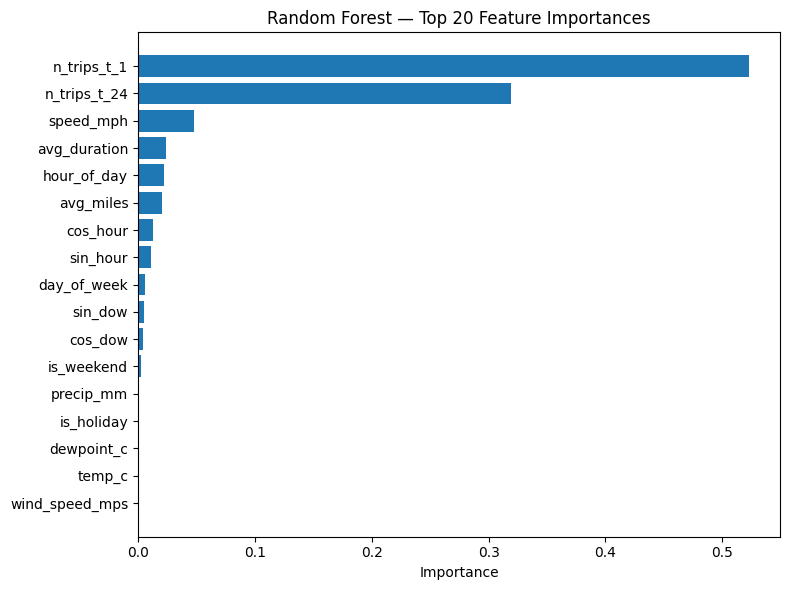

In [ ]:
rf_path = os.path.join(MODEL_OUT, "rf_best")


# Load the bare model (no warnings, no peeking)
rf_stage = RandomForestRegressionModel.load(rf_path)

# Assembler inputs during training were imputed columns "<col>__imp"
assembler_inputs = [f"{c}__imp" for c in CAND_TREE_FEATURES]

# Map importances back to base names
imp = np.array(rf_stage.featureImportances.toArray())
m = min(len(imp), len(assembler_inputs))
names = [c.replace("__imp", "") for c in assembler_inputs[:m]]

rf_imp_df = (pd.DataFrame({"feature": names, "importance": imp[:m]})
               .sort_values("importance", ascending=False)
               .reset_index(drop=True))

display(rf_imp_df.head(25))
rf_imp_df.to_csv(os.path.join(REPORT_OUT,
                              "rf_feature_importances.csv"), index=False)

# Plot top-20
plt.figure(figsize=(8, 6))
plt.barh(rf_imp_df["feature"].head(20)[::-1],
         rf_imp_df["importance"].head(20)[::-1])
plt.xlabel("Importance")
plt.title("Random Forest — Top 20 Feature Importances")
plt.tight_layout()
plt.show()

Short-term lag features (`n_trips_t_1`, `n_trips_t_24`) dominate — confirming the EDA finding that recent demand is the strongest signal for current profitability. Time-of-day metrics contribute next, followed by trip characteristics. Weather variables are minor contributors within the Jan–Jun window, but are retained for robustness under extreme conditions.


---

## 5. Evaluation on 2025 Test Set

The final RF model is evaluated on the held-out Jan–Jun 2025 test period — data the model has never seen, from a year affected by the Congestion Pricing Program. This is the true measure of generalisation.

### 5.1 Loading 2025 Test Data


In [ ]:
def load_2025_test():
    base = (spark.read.parquet(EDA_JOIN)
            .pipe(_ensure_ts, 'pickup_hour_local')
            .pipe(_ensure_calendar, 'pickup_hour_local')
            .pipe(_ensure_cyclic)
            .filter(F.col('year') == 2025)
            .dropDuplicates(KEYS))

    if TARGET_COL in base.columns:
        base = base.drop(TARGET_COL)

    y2025 = (spark.read.option('recursiveFileLookup', 'true').parquet(TARGET_2025)
             .pipe(_ensure_ts, 'pickup_hour_local')
             .select(*KEYS, TARGET_COL)
             .dropDuplicates(KEYS))

    keep_x = [c for c in set(KEYS + FEATURE_COLS +
                             CYCLIC_COLS) if c in base.columns]
    df = (base.alias('x')
          .join(y2025.alias('y'), KEYS, 'inner')
          .select(*[F.col(f'x.{c}').alias(c) for c in keep_x],
                  F.col(f'y.{TARGET_COL}').alias(TARGET_COL)))

    df = _cast_for_ml(df, FEATURE_COLS, TARGET_COL)
    df = add_time_and_logs(df)
    df = _cast_feats(df, TREE_FEATURES)
    return df.persist(StorageLevel.DISK_ONLY)


test_df = load_2025_test()
print(f'2025 test rows: {test_df.count():,}')

2025 test rows: 1,089,557


### 5.2 Test Set Metrics

Results on the full Jan–Jun 2025 test period — entirely unseen, post-congestion pricing data.


In [ ]:
rf_pred_2025 = rf_model.transform(test_df)
test_mets = eval_metrics(rf_pred_2025, TARGET_COL, 'prediction')

print('RF — 2025 Test Set:')
print(f"  RMSE : {test_mets['rmse']:.2f}")
print(f"  MAE  : {test_mets['mae']:.2f}")
print(f"  R²   : {test_mets['r2']:.3f}")
print(f"\nValidation vs Test gap:")
print(f"  ΔRMSE: {test_mets['rmse'] - rf_mets['rmse']:+.2f}  "
      f"ΔMAE: {test_mets['mae'] - rf_mets['mae']:+.2f}  "
      f"ΔR²: {test_mets['r2'] - rf_mets['r2']:+.3f}")

rf_pred_2025.select(*KEYS, TARGET_COL, 'prediction').write.mode('overwrite').parquet(
    os.path.join(REPORT_OUT, 'predictions_2025'))
with open(os.path.join(REPORT_OUT, 'rf_test_metrics.json'), 'w') as f:
    json.dump(test_mets, f, indent=2)

RF — 2025 Test Set:
  RMSE : 32.42
  MAE  : 17.26
  R²   : 0.900

Validation vs Test gap:
  ΔRMSE: +0.91  ΔMAE: +0.18  ΔR²: -0.004


The validation-to-test gap is minimal — RMSE increases by less than 1 point, R² drops by 0.004. This confirms the model generalises well to the post-congestion pricing environment without retraining, validating the forward-chaining split design.


### 5.3 Actual vs Predicted — Daily Mean (Jan–Jun 2025)


2025 overall (Jan–Jun): {'rmse': 32.41520386368883, 'r2': 0.9004094380715835, 'mae': 17.264059988655966}


,month,rmse,mae,r2
0,1,34.751607,17.341708,0.882497
1,2,30.827901,17.065944,0.913927
2,3,33.323825,17.606878,0.899008
3,4,28.190034,15.871130,0.919007
4,5,33.556549,17.916478,0.896376
5,6,33.087676,17.723943,0.893982


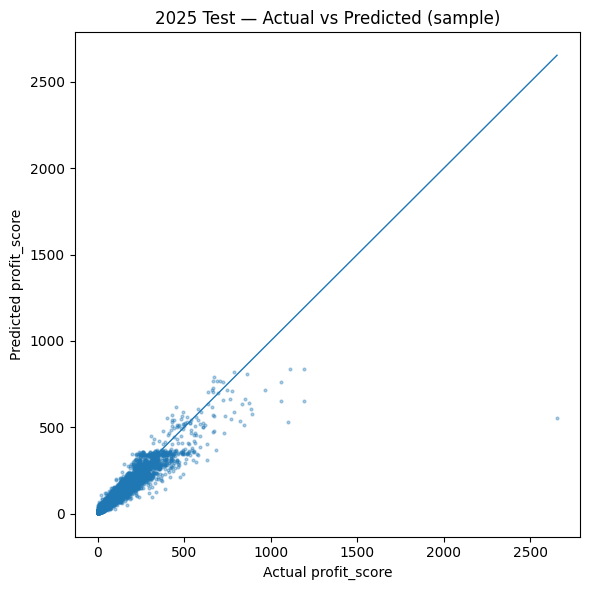

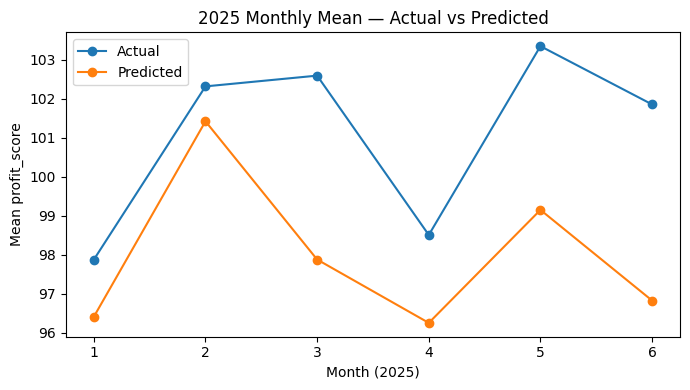

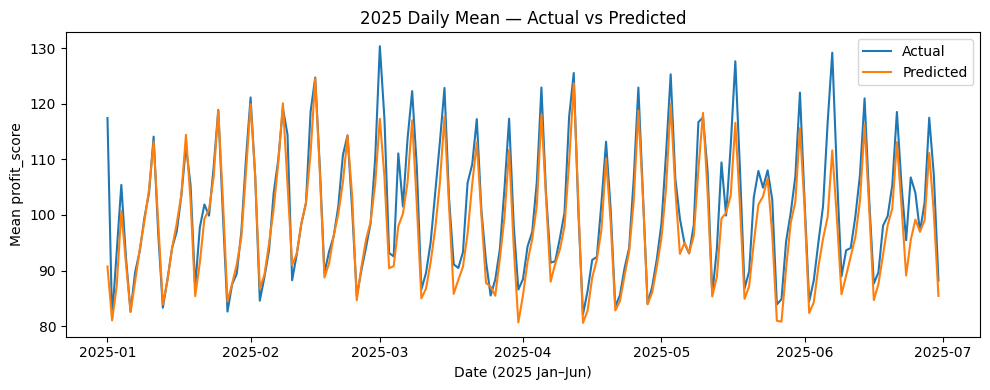

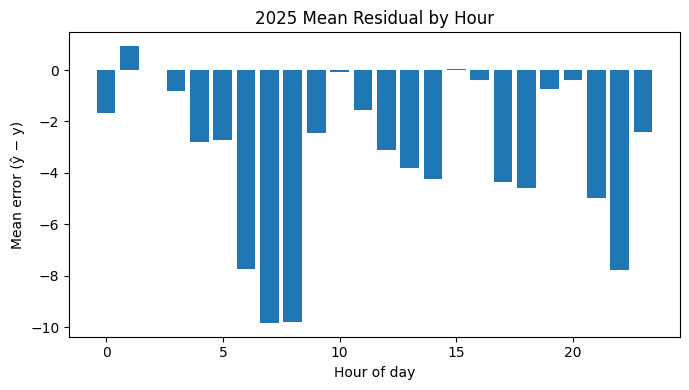

Saved predictions to: ../data/curated/models/eval/predictions_2025


In [ ]:
# ---------- 4) Evaluate + plots ----------
has_y = TARGET_COL in rf_pred_2025.columns
OUT_DIR = "../data/curated/models/eval"


def eval_metrics(df, y=TARGET_COL, yhat="yhat"):
    e_rmse = RegressionEvaluator(
        labelCol=y, predictionCol=yhat, metricName="rmse")
    e_r2 = RegressionEvaluator(labelCol=y, predictionCol=yhat, metricName="r2")
    e_mae = RegressionEvaluator(
        labelCol=y, predictionCol=yhat, metricName="mae")
    return {"rmse": float(e_rmse.evaluate(df)),
            "r2":   float(e_r2.evaluate(df)),
            "mae":  float(e_mae.evaluate(df))}


if has_y:
    overall = eval_metrics(rf_pred_2025)
    print("2025 overall (Jan–Jun):", overall)

    # by-month (RMSE/MAE + exact R²)
    by_month = (
        rf_pred_2025.groupBy("month")
        .agg(
            F.count("*").alias("n"),
            F.sqrt(F.avg((F.col("yhat")-F.col(TARGET_COL))**2)).alias("rmse"),
            F.avg(F.abs(F.col("yhat")-F.col(TARGET_COL))).alias("mae"),
            F.sum((F.col(TARGET_COL)-F.col("yhat"))**2).alias("ss_res"),
            F.sum(F.col(TARGET_COL)).alias("sum_y"),
            F.sum(F.col(TARGET_COL)*F.col(TARGET_COL)).alias("sum_y2"),
        )
        .withColumn("r2",
                    1 - F.col("ss_res") / (F.col(
                        "sum_y2") - (F.col("sum_y")**2)/F.col("n")))
        .orderBy("month").select("month", "rmse", "mae", "r2").toPandas()
    )
    display(by_month)

    # Plots (sample scatter; monthly and daily trend; residuals by hour)
    sample_pdf = (rf_pred_2025.select(TARGET_COL, "yhat")
                  .sample(False, 0.01, seed=SEED).toPandas())
    if len(sample_pdf) > 0:
        plt.figure(figsize=(6, 6))
        plt.scatter(sample_pdf[TARGET_COL],
                    sample_pdf["yhat"], s=4, alpha=0.35)
        lo = min(sample_pdf[TARGET_COL].min(), sample_pdf["yhat"].min())
        hi = max(sample_pdf[TARGET_COL].max(), sample_pdf["yhat"].max())
        plt.plot([lo, hi], [lo, hi], linewidth=1)
        plt.xlabel("Actual profit_score")
        plt.ylabel("Predicted profit_score")
        plt.title("2025 Test — Actual vs Predicted (sample)")
        plt.tight_layout()
        plt.show()

    monthly_pdf = (
        rf_pred_2025.groupBy("month")
        .agg(F.avg(TARGET_COL).alias("actual"), F.avg("yhat").alias("pred"))
        .orderBy("month").toPandas()
    )
    plt.figure(figsize=(7, 4))
    plt.plot(monthly_pdf["month"], monthly_pdf["actual"],
             marker="o", label="Actual")
    plt.plot(monthly_pdf["month"], monthly_pdf["pred"],
             marker="o", label="Predicted")
    plt.xlabel("Month (2025)")
    plt.ylabel("Mean profit_score")
    plt.title("2025 Monthly Mean — Actual vs Predicted")
    plt.legend()
    plt.tight_layout()
    plt.show()

    daily_pdf = (
        rf_pred_2025.withColumn("date", F.to_date("pickup_hour_local"))
        .groupBy("date").agg(F.avg(TARGET_COL).alias(
            "actual"), F.avg("yhat").alias("pred"))
        .orderBy("date").toPandas()
    )
    plt.figure(figsize=(10, 4))
    plt.plot(daily_pdf["date"], daily_pdf["actual"], label="Actual")
    plt.plot(daily_pdf["date"], daily_pdf["pred"],   label="Predicted")
    plt.xlabel("Date (2025 Jan–Jun)")
    plt.ylabel("Mean profit_score")
    plt.title("2025 Daily Mean — Actual vs Predicted")
    plt.legend()
    plt.tight_layout()
    plt.show()

    hour_pdf = (
        rf_pred_2025.withColumn("hour", F.hour("pickup_hour_local"))
        .groupBy("hour").agg(F.avg(
            F.col("yhat")-F.col(TARGET_COL)).alias("mean_error"))
        .orderBy("hour").toPandas()
    )
    plt.figure(figsize=(7, 4))
    plt.bar(hour_pdf["hour"], hour_pdf["mean_error"])
    plt.xlabel("Hour of day")
    plt.ylabel("Mean error (ŷ − y)")
    plt.title("2025 Mean Residual by Hour")
    plt.tight_layout()
    plt.show()

    # Save metrics
    with open(os.path.join(OUT_DIR,
                           "regression_overall_2025.json"), "w") as f:
        json.dump(overall, f, indent=2)
    by_month.to_json(os.path.join(OUT_DIR, "regression_by_month_2025.json"),
                     orient="records", indent=2)

# Save predictions
(rf_pred_2025
 .select(*KEYS, "year", "month",
         *([TARGET_COL] if TARGET_COL in rf_pred_2025.columns else []),
         F.col("yhat").alias("prediction"))
 .coalesce(1).write.mode("overwrite")
 .parquet(os.path.join(OUT_DIR, "predictions_2025")))
print("Saved predictions to:", os.path.join(OUT_DIR, "predictions_2025"))

The model tracks peaks and troughs well across the full 6-month horizon. The slight underestimation visible in March and May reflects regression-to-the-mean behaviour common in ensemble methods — the model dampens extreme highs. For the recommendation system, this conservatism is acceptable: drivers still get directed to the right zones even if the absolute profit estimate is slightly low.


---

## Summary

|      | Ridge (Val) | RF (Val) | RF (Test 2025) |
| ---- | ----------- | -------- | -------------- |
| RMSE | 35.17       | 31.51    | **32.42**      |
| MAE  | 18.46       | 17.08    | **17.26**      |
| R²   | 0.880       | 0.904    | **0.900**      |

The Random Forest generalises cleanly to the unseen 2025 test period, with metrics almost identical to validation. The recommendation system correctly identifies ~3 of 5 top zones per hour and keeps picks geographically spread at ~8km mean pairwise distance — giving drivers real choices rather than all pointing to the same hotspot.
